# SpaceX Falcon 9 Data Wrangling

**IBM Applied Data Science Capstone**  
Repository owner: `phuonganhdt220391`

## Objectives

- Inspect the collected launch dataset.
- identify unsuccessful landing outcomes.
- create the binary target `Class` (`1` = successful landing, `0` = unsuccessful).
- save the labeled data to `dataset_part_2.csv`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
DATA_DIR = Path(".")
data = pd.read_csv(DATA_DIR / "dataset_part_1.csv")
print("Shape:", data.shape)
data.head()

Shape: (90, 17)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


In [2]:
missing = data.isna().sum().sort_values(ascending=False)
missing[missing > 0]

LandingPad    26
dtype: int64

In [3]:
outcome_counts = data["Outcome"].value_counts(dropna=False)
outcome_counts

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64

In [4]:
bad_outcomes = [
    "False ASDS", "False Ocean", "False RTLS", "None ASDS", "None None"
]
landing_class = data["Outcome"].apply(lambda value: 0 if value in bad_outcomes else 1)
data["Class"] = landing_class.astype(int)

print(data["Class"].value_counts().sort_index())
print(f"Overall successful-landing rate: {data['Class'].mean():.1%}")
data[["FlightNumber", "Outcome", "Class"]].head(12)

Class
0    30
1    60
Name: count, dtype: int64
Overall successful-landing rate: 66.7%


,FlightNumber,Outcome,Class
0,1,None None,0
1,2,None None,0
2,3,None None,0
3,4,False Ocean,0
4,5,None None,0
5,6,None None,0
6,7,True Ocean,1
7,8,True Ocean,1
8,9,None None,0
9,10,None None,0


In [5]:
success_by_site = (
    data.groupby("LaunchSite", as_index=False)["Class"]
        .mean()
        .sort_values("Class", ascending=False)
)
success_by_site["SuccessRate"] = success_by_site["Class"]
success_by_site.drop(columns="Class")

,LaunchSite,SuccessRate
1,KSC LC 39A,0.772727
2,VAFB SLC 4E,0.769231
0,CCAFS SLC 40,0.600000


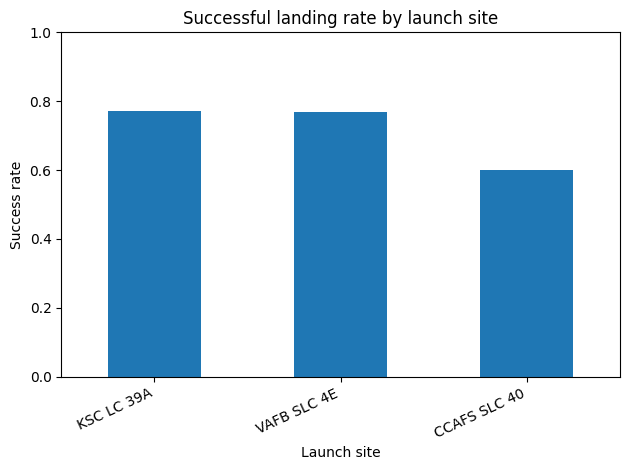

In [6]:
ax = success_by_site.plot(
    x="LaunchSite", y="SuccessRate", kind="bar", legend=False,
    title="Successful landing rate by launch site"
)
ax.set_xlabel("Launch site")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [7]:
output_path = DATA_DIR / "dataset_part_2.csv"
data.to_csv(output_path, index=False)
print(f"Saved labeled dataset: {output_path} ({len(data)} rows)")

Saved labeled dataset: dataset_part_2.csv (90 rows)


## Conclusion

The landing outcomes were converted into a machine-learning target. The
resulting `dataset_part_2.csv` is used by the EDA and predictive-analysis
notebooks in this repository.